In [ ]:
!git clone https://github.com/minwoosun/UCE.git

Cloning into 'UCE'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 151 (delta 66), reused 47 (delta 47), pack-reused 71 (from 1)
Receiving objects: 100% (151/151), 67.75 KiB | 5.65 MiB/s, done.
Resolving deltas: 100% (80/80), done.


In [ ]:
%cd UCE

/content/UCE


In [ ]:
! pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 171.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 202.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 194.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existin

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Upload dataset


In [ ]:
data_path = "/content/drive/MyDrive/GP_datasets/HBECs/HBECs.h5ad"

## Run UCE model on loaded data

In [ ]:
! python eval_single_anndata.py --adata_path {data_path} --dir "./" --model_loc "minwoosun/uce-100m"


species_chrom.csv: 4.10MB [00:00, 19.8MB/s]
all_tokens.torch: 100% 2.98G/2.98G [00:24<00:00, 121MB/s]
species_offsets.pkl: 100% 139/139 [00:00<00:00, 342B/s]
protein_embeddings/Danio_rerio.GRCz11.ge(…): 100% 537M/537M [00:03<00:00, 179MB/s]
protein_embeddings/Homo_sapiens.GRCh38.g(…): 100% 411M/411M [00:04<00:00, 93.2MB/s]
protein_embeddings/Macaca_fascicularis.M(…): 100% 315M/315M [00:01<00:00, 196MB/s]
protein_embeddings/Macaca_mulatta.Mmul_1(…): 100% 348M/348M [00:04<00:00, 79.0MB/s]
protein_embeddings/Microcebus_murinus.Mm(…): 100% 302M/302M [00:03<00:00, 94.1MB/s]
protein_embeddings/Mus_musculus.GRCm39.g(…): 100% 464M/464M [00:02<00:00, 231MB/s]
protein_embeddings/Sus_scrofa.Sscrofa11.(…): 100% 327M/327M [00:02<00:00, 126MB/s]
protein_embeddings/Xenopus_tropicalis.Xe(…): 100% 281M/281M [00:02<00:00, 99.9MB/s]
Download Complete!
Proccessing HBECs
3023.0
HBECs (17451, 13278)
Wrote Shapes Dict
13278
Max Code: 613
config.json: 100% 115/115 [00:00<00:00, 905kB/s]
pytorch_model.bin: 100

In [ ]:
!pip install umap-learn matplotlib

In [ ]:
import scanpy as sc

# Read the .h5ad file
adata = sc.read_h5ad("/content/UCE/HBECs_uce_adata.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 17451 × 13278
    obs: 'ID', 'Sex', 'Age', 'Smoking', 'UMI count', 'Gene count', 'Cell type', 'MT ratio', 'n_genes'
    var: 'n_cells'
    obsm: 'X_uce'


In [ ]:
adata.write_h5ad("/content/drive/MyDrive/GP_datasets/HBECs/HBECs_uce_adata.h5ad")

# Build a cell-type classifier using UCE embeddings

In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = adata.obsm["X_uce"]
y = adata.obs["Cell type"]

# logistic regression
y_pred_lr = cross_val_predict(clf, X, y, cv=kf)

# knn
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

y_pred_knn = cross_val_predict(knn, X, y, cv=kf)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

In [ ]:
def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

=== Logistic Regression ===
Accuracy: 0.7764024984241591
               precision    recall  f1-score   support

       Basal1       0.79      0.90      0.84      1923
       Basal2       0.80      0.82      0.81      1922
       Basal3       0.70      0.42      0.52       556
Basal_Mitotic       0.95      0.62      0.75       305
    Ciliated1       0.88      0.95      0.91      2150
    Ciliated2       0.84      0.57      0.68       614
         Club       0.72      0.84      0.78      3347
        FOXN4       1.00      0.19      0.32        80
   Fibroblast       0.98      0.99      0.98       377
       Goblet       0.79      0.78      0.79       980
     Ionocyte       0.98      0.48      0.65       124
   Secretory1       0.73      0.68      0.70      1728
   Secretory2       0.73      0.69      0.71      2871
   Secretory3       0.67      0.49      0.57       474

     accuracy                           0.78     17451
    macro avg       0.83      0.67      0.72     17451
 weigh

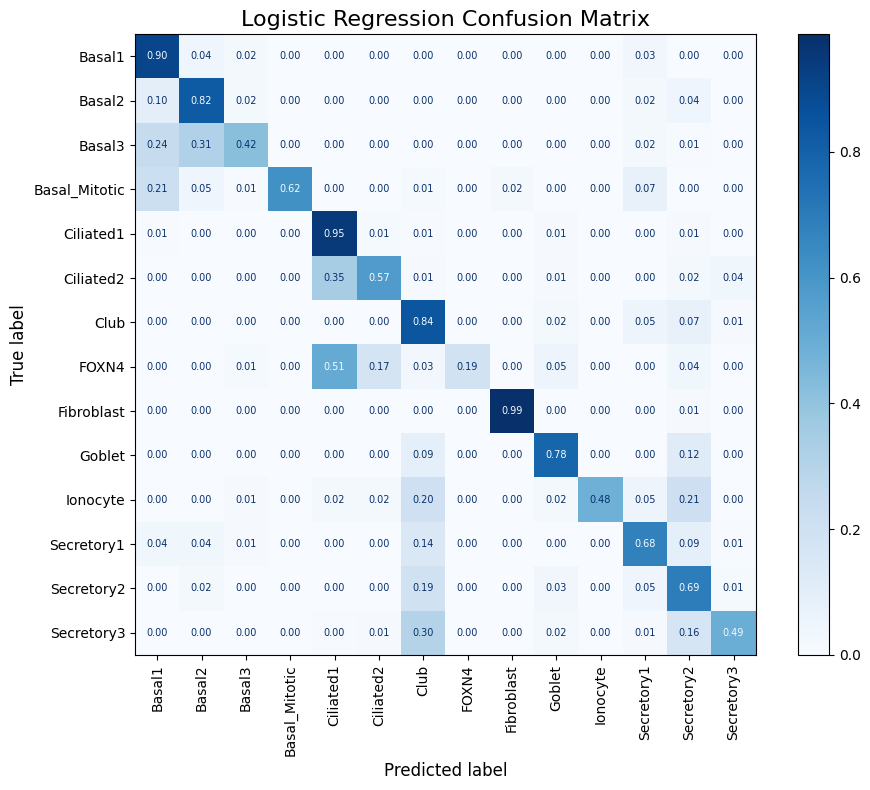


=== k-NN ===
Accuracy: 0.7737665463297232
               precision    recall  f1-score   support

       Basal1       0.78      0.92      0.84      1923
       Basal2       0.81      0.81      0.81      1922
       Basal3       0.83      0.46      0.59       556
Basal_Mitotic       0.95      0.69      0.80       305
    Ciliated1       0.89      0.95      0.92      2150
    Ciliated2       0.89      0.60      0.71       614
         Club       0.69      0.85      0.76      3347
        FOXN4       1.00      0.44      0.61        80
   Fibroblast       0.97      0.98      0.98       377
       Goblet       0.79      0.74      0.77       980
     Ionocyte       0.99      0.61      0.76       124
   Secretory1       0.71      0.66      0.69      1728
   Secretory2       0.74      0.65      0.69      2871
   Secretory3       0.69      0.46      0.55       474

     accuracy                           0.77     17451
    macro avg       0.84      0.70      0.75     17451
 weighted avg       

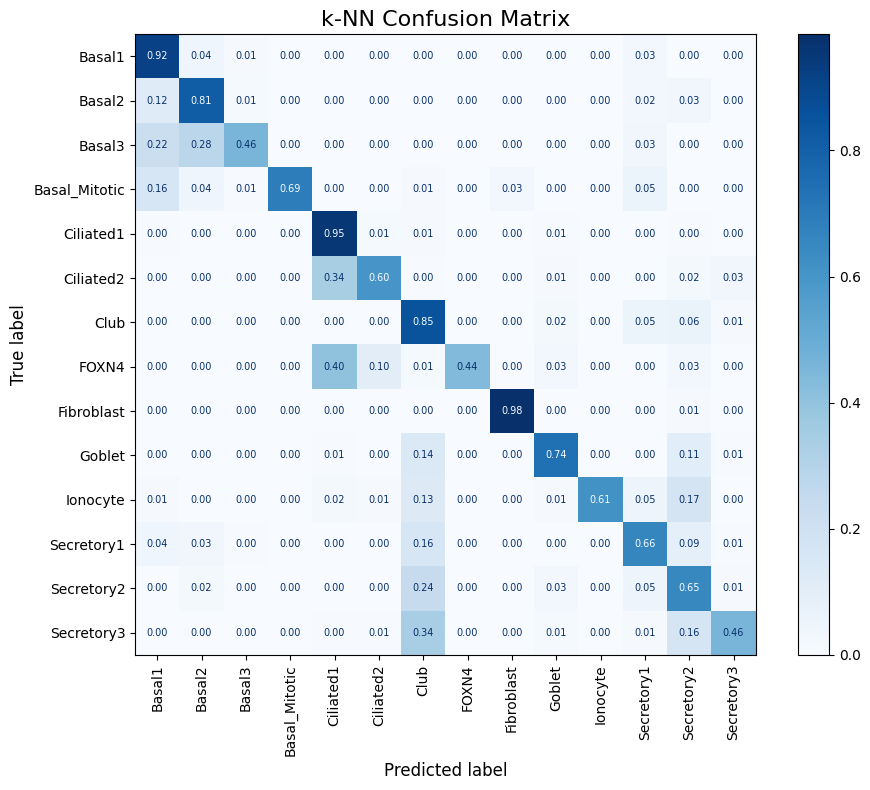

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Calculate accuracy

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y, y_pred_lr))
print(classification_report(y, y_pred_lr))
plot_cm(y, y_pred_lr, "Logistic Regression Confusion Matrix")

print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y, y_pred_knn))
print(classification_report(y, y_pred_knn))
plot_cm(y, y_pred_knn, "k-NN Confusion Matrix")

# Visualize UCE embeddings through UMAP

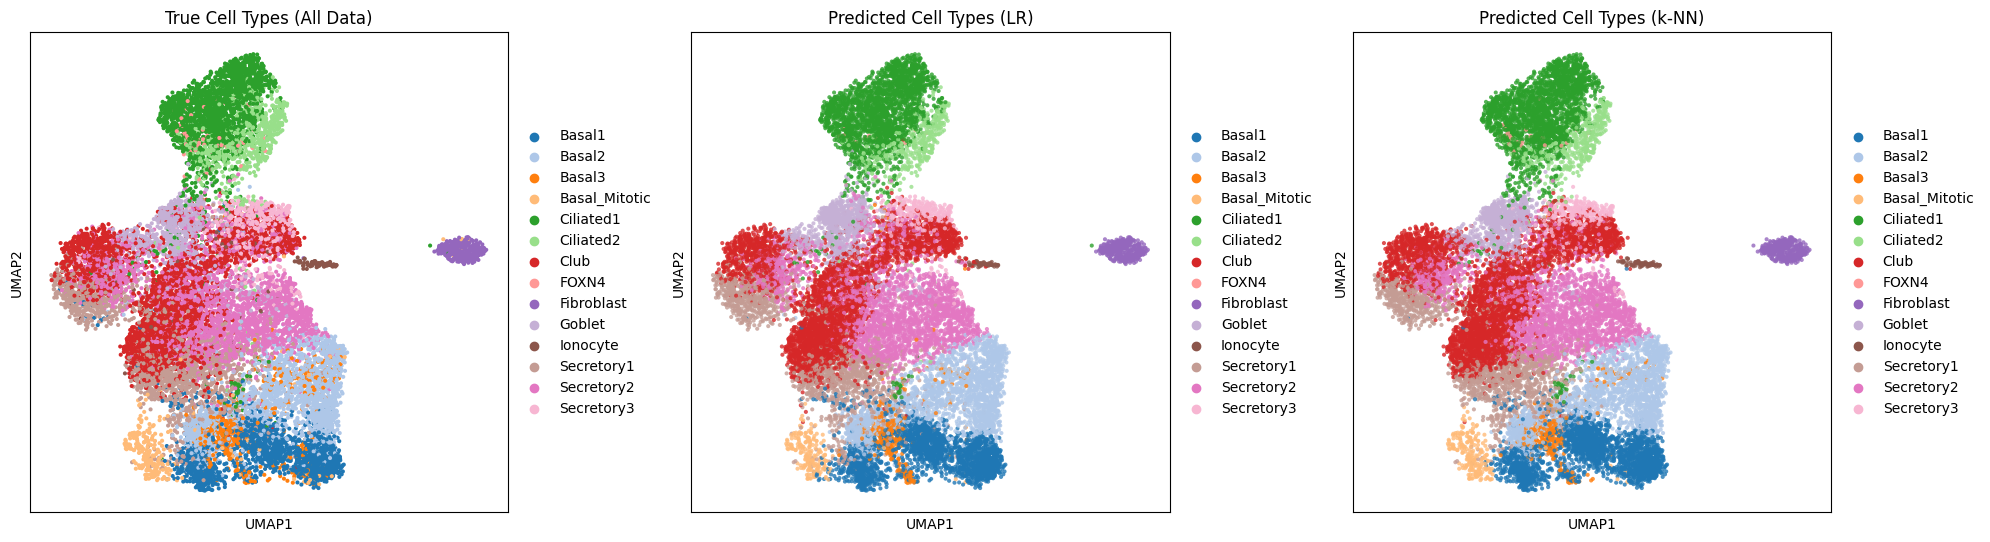

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

# Fill missing predicted labels
adata.obs['y_pred_lr'] = pd.Series(y_pred_lr, index=adata.obs_names).astype(str).fillna('Unassigned')
adata.obs['y_pred_knn'] = pd.Series(y_pred_knn, index=adata.obs_names).astype(str).fillna('Unassigned')

# PCA + neighbors + UMAP on full data
sc.pp.neighbors(adata, use_rep='X_uce', n_neighbors=15)
sc.tl.umap(adata)


# Unified label categories
all_labels = pd.Categorical(pd.concat([
    pd.Series(adata.obs['Cell type'].cat.categories),
    pd.Series(pd.Categorical(adata.obs['y_pred_lr']).categories),
    pd.Series(pd.Categorical(adata.obs['y_pred_knn']).categories)
], ignore_index=True)).categories

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map['Unassigned'] = 'lightgray'

# Create side-by-side figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# True labels
sc.pl.umap(
    adata,
    color='Cell type',
    ax=axes[0],
    show=False,
    size=35,
    palette=[color_map[x] for x in all_labels],
)
axes[0].set_title('True Cell Types (All Data)')

# Predicted labels (lr)
sc.pl.umap(
    adata,
    color='y_pred_lr',
    ax=axes[1],
    show=False,
    size=35,
    alpha=0.8,
    palette=[color_map[x] for x in all_labels],
)
axes[1].set_title('Predicted Cell Types (LR)')

# Predicted labels (knn)
sc.pl.umap(
    adata,
    color='y_pred_knn',
    ax=axes[2],
    show=False,
    size=35,
    alpha=0.8,
    palette=[color_map[x] for x in all_labels],
)
axes[2].set_title('Predicted Cell Types (k-NN)')

# # Unified legend
# handles = [Patch(color=color_map[label], label=label) for label in all_labels]
# fig.legend(handles=handles, title='Cell Type / Predicted Labels', loc='lower center', ncol=6, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()
